In [5]:
# Levi Félix Barbosa - 579420

import numpy as np
import matplotlib.pyplot as plt

carros = np.genfromtxt('vehicle.csv', delimiter=',')

X_puro = carros[:,:-1]
y_puro = carros[:,-1]

N = len(X_puro)

np.random.seed(42)
indices = np.random.permutation(N)
X = X_puro[indices]
y = y_puro[indices]

tam_treino = int(0.8*N)
tam_teste = N - tam_treino

X_treino = X[:tam_treino]
y_treino = y[:tam_treino]

X_teste = X[tam_treino:]
y_teste = y[tam_treino:]

In [ ]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def treinar_reg_log_multiclasse(X, y, alpha, lambd, num_classes, iteracoes):

    m, n = X.shape
    
    y_one_hot = np.eye(num_classes)[y.reshape(-1).astype(int)]
   
        
    w = np.zeros((n, num_classes))
    b = np.zeros(num_classes)
    loss_hist = []
    
    for t in range(iteracoes):
    
        z = X @ w + b
        y_pred = softmax(z)
        
        # para evitar erros: (ia disse que era bom)
        y_pred_ok = np.clip(y_pred, 1e-15, 1 - 1e-15)
        
        loss = -np.mean(np.sum(y_one_hot * np.log(y_pred_ok), axis=1)) + lambd * np.sum(w**2) / (2*m)
        loss_hist.append(loss)
        
        e = y_pred - y_one_hot
        w = w - alpha * (X.T @ e) / m - alpha * lambd * w / m
        b = b - alpha * np.mean(e, axis=0) 
        
    return w, b, loss_hist


def k_fold_split(X, y, k, alpha, lambd):
    
    indices_kfold = np.arange(len(X))
    folds = np.array_split(indices_kfold, k)
    
    resultados = []
    resultados_por_classe = {c: [] for c in range(4)}

    for i in range(k):
        
        val_idx = folds[i]
        treino_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_treinov_puro, X_val_puro = X[treino_idx], X[val_idx]
        y_treinov, y_val = y[treino_idx], y[val_idx]
        m = len(X_treinov_puro)

        media_treino = np.mean(X_treinov_puro, axis=0)
        desvio_treino = np.std(X_treinov_puro, axis=0)
        
        X_treinov = (X_treinov_puro - media_treino) / desvio_treino
        X_val = (X_val_puro - media_treino) / desvio_treino
                
        
        w, b, loss_hist = treinar_reg_log_multiclasse(X_treinov, y_treinov, alpha, lambd, 4, 5000)

        y_prob_val = softmax(X_val @ w + b)
        y_pred_val = np.argmax(y_prob_val, axis=1)

        acc = np.mean(y_pred_val == y_val)
        resultados.append(acc)

        for c in range(4):
            classe = (y_val == c)
            
            if np.sum(classe) > 0: 
                acc_c = np.mean(y_pred_val[classe] == c)
                resultados_por_classe[c].append(acc_c)

    media = np.mean(resultados)
    desvio = np.std(resultados)

    media_cls = {c: np.mean(resultados_por_classe[c]) for c in range(4)}
    desvio_cls = {c: np.std(resultados_por_classe[c]) for c in range(4)}

    return media, desvio, media_cls, desvio_cls

# agora, o grid search
alpha_lista = [0.001, 0.01, 0.1, 1.0]
lambd_lista = [0.001, 0.01, 0.1, 1.0, 10.0]

print('Regressão Logística \n')

teste = []
for i in alpha_lista:
    for j in lambd_lista:
        acc, desvio, acc_cls, desvio_cls = k_fold_split(X_treino, y_treino, 10, i, j)
        teste.append((i, j, acc, desvio, acc_cls, desvio_cls))
        print(f'alpha: {i}, lambda: {j} => acurácia média: {acc:.4f}, desvio: {desvio:.4f}')

teste.sort(key=lambda x: x[2], reverse=True)
melhor_alpha = teste[0][0]
melhor_lambda = teste[0][1]
melhor_acc = teste[0][2]
melhor_desvio = teste[0][3]
melhor_acc_cls = teste[0][4]
melhor_desvio_cls = teste[0][5]
print('\n')
print(f'Melhor alpha: {melhor_alpha}, Melhor lambda: {melhor_lambda}, acurácia média: {teste[0][2]:.4f}, desvio padrão: {teste[0][3]:.4f}')

print('\n Acurácia por Classe \n')
for c in range(4):
    print(f'Classe {c} -> Acurácia Média: {melhor_acc_cls[c]:.4f} (Desvio: {melhor_desvio_cls[c]:.4f})')

Regressão Logística 

alpha: 0.001, lambda: 0.001 => acurácia média: 0.6521, desvio: 0.0700
alpha: 0.001, lambda: 0.01 => acurácia média: 0.6521, desvio: 0.0700
alpha: 0.001, lambda: 0.1 => acurácia média: 0.6521, desvio: 0.0700
alpha: 0.001, lambda: 1.0 => acurácia média: 0.6521, desvio: 0.0700
alpha: 0.001, lambda: 10.0 => acurácia média: 0.6507, desvio: 0.0678
alpha: 0.01, lambda: 0.001 => acurácia média: 0.7500, desvio: 0.0207
alpha: 0.01, lambda: 0.01 => acurácia média: 0.7500, desvio: 0.0207
alpha: 0.01, lambda: 0.1 => acurácia média: 0.7500, desvio: 0.0207
alpha: 0.01, lambda: 1.0 => acurácia média: 0.7470, desvio: 0.0218
alpha: 0.01, lambda: 10.0 => acurácia média: 0.7396, desvio: 0.0387
alpha: 0.1, lambda: 0.001 => acurácia média: 0.8003, desvio: 0.0316
alpha: 0.1, lambda: 0.01 => acurácia média: 0.7989, desvio: 0.0329
alpha: 0.1, lambda: 0.1 => acurácia média: 0.7959, desvio: 0.0307
alpha: 0.1, lambda: 1.0 => acurácia média: 0.7884, desvio: 0.0266
alpha: 0.1, lambda: 10.0 => 

(Regressão Logística) 

Acurácia final no conjunto de Teste: 0.7235


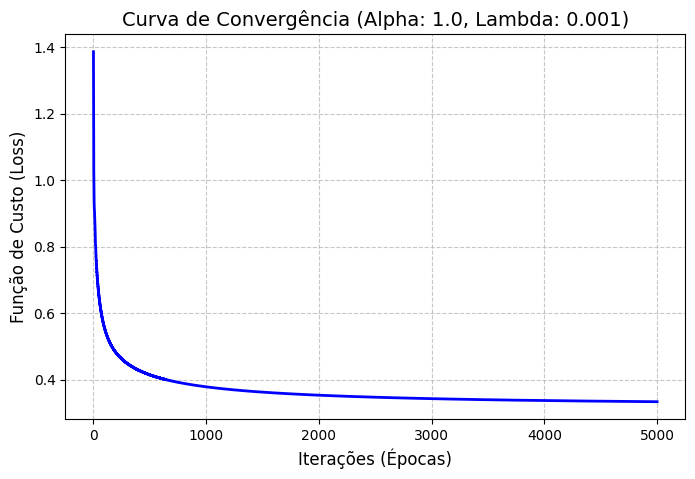

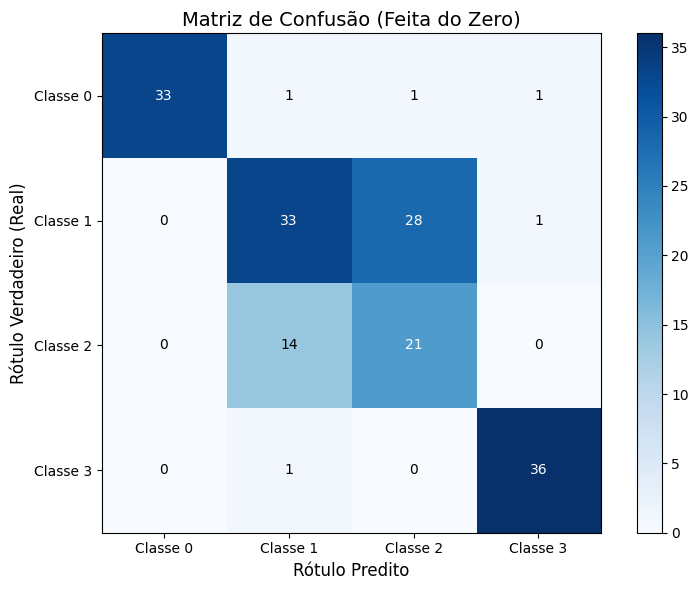

In [9]:
# agora vamos treinar o modelo todo com esse alpha e esse lambda

X_treino_norm = (X_treino - np.mean(X_treino, axis=0)) / np.std(X_treino, axis=0)
X_teste_norm = (X_teste - np.mean(X_treino, axis=0)) / np.std(X_treino, axis=0)

w_final, b_final, loss_hist = treinar_reg_log_multiclasse(X_treino_norm, y_treino, melhor_alpha, melhor_lambda, 4, 5000)

y_prob_teste = softmax(X_teste_norm @ w_final + b_final)
y_pred_teste = np.argmax(y_prob_teste, axis=1)
acc_final = np.mean(y_pred_teste == y_teste)

print('(Regressão Logística) \n')
print(f'Acurácia final no conjunto de Teste: {acc_final:.4f}')


plt.figure(figsize=(8, 5)) 
plt.plot(loss_hist, color='blue', linewidth=2)
plt.title(f'Curva de Convergência (Alpha: {melhor_alpha}, Lambda: {melhor_lambda})', fontsize=14)
plt.xlabel('Iterações (Épocas)', fontsize=12)
plt.ylabel('Função de Custo (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


def calcular_matriz_confusao(y_real, y_pred, num_classes):
    
    matriz = np.zeros((num_classes, num_classes), dtype=int)
    for real, pred in zip(y_real, y_pred):
        matriz[int(real), int(pred)] += 1
    return matriz

def plotar_matriz_confusao(matriz, num_classes):
    plt.figure(figsize=(8, 6))
    
    
    plt.imshow(matriz, interpolation='nearest', cmap='Blues')
    plt.title('Matriz de Confusão (Feita do Zero)', fontsize=14)
    plt.colorbar()
    
    ticks = np.arange(num_classes)
    nomes_classes = [f'Classe {i}' for i in range(num_classes)]
    plt.xticks(ticks, nomes_classes)
    plt.yticks(ticks, nomes_classes)
    plt.ylabel('Rótulo Verdadeiro (Real)', fontsize=12)
    plt.xlabel('Rótulo Predito', fontsize=12)

    limite_cor = matriz.max() / 2.0 
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, str(matriz[i, j]),
                     horizontalalignment="center",
                     verticalalignment="center",
                     color="white" if matriz[i, j] > limite_cor else "black")
            
    plt.tight_layout()
    plt.show()

num_classes = 4
matriz_final = calcular_matriz_confusao(y_teste, y_pred_teste, num_classes)
plotar_matriz_confusao(matriz_final, num_classes)

In [ ]:
# agora, vamos ao gda

def treinar_gda(X, y, num_classes):

    n_features = X.shape[1]

    phis = np.zeros(num_classes)               
    mus = np.zeros((num_classes, n_features))   
    sigmas = []                                 
    
    for c in range(num_classes):
       
        X_c = X[y == c]
        m_c = len(X_c)
        
        phis[c] = m_c / len(X)
        
       
        mus[c] = np.mean(X_c, axis=0)
        
       
        diff = X_c - mus[c]
        
        sigma_c = (diff.T @ diff) / m_c + np.eye(n_features) * 1e-6 # ia disse que eu precisava botar 1e-6 pra evitar erros)
        sigmas.append(sigma_c)
        
    return phis, mus, sigmas

def prever_gda(X, phis, mus, sigmas, num_classes):
    
    m = len(X)
    scores = np.zeros((m, num_classes))
    
    for c in range(num_classes):
        
        sigma_inv = np.linalg.inv(sigmas[c])
        
        sinal, logdet = np.linalg.slogdet(sigmas[c]) 
        
       
        diff = X - mus[c]
        
        
        distancia = np.sum((diff @ sigma_inv) * diff, axis=1)
        
        
        scores[:, c] = np.log(phis[c]) - 0.5 * logdet - 0.5 * distancia
        
    
    return np.argmax(scores, axis=1)

In [11]:
def k_fold_split_gda(X, y, k, num_classes):
    
    indices_kfold = np.arange(len(X))
    folds = np.array_split(indices_kfold, k)
    
    resultados_globais = []
    resultados_por_classe = {c: [] for c in range(num_classes)}

    for i in range(k):
        val_idx = folds[i]
        treino_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_treinov_puro, X_val_puro = X[treino_idx], X[val_idx]
        y_treinov, y_val = y[treino_idx], y[val_idx]

        
        media_treino = np.mean(X_treinov_puro, axis=0)
        desvio_treino = np.std(X_treinov_puro, axis=0) + 1e-8
        
        X_treinov = (X_treinov_puro - media_treino) / desvio_treino
        X_val = (X_val_puro - media_treino) / desvio_treino
                
        phis, mus, sigmas = treinar_gda(X_treinov, y_treinov, num_classes)

        y_pred_val = prever_gda(X_val, phis, mus, sigmas, num_classes)

        acc = np.mean(y_pred_val == y_val)
        resultados_globais.append(acc)

        for c in range(num_classes):
            mascara = (y_val == c)
            if np.sum(mascara) > 0:
                acc_c = np.mean(y_pred_val[mascara] == c)
                resultados_por_classe[c].append(acc_c)

    media_global = np.mean(resultados_globais)
    desvio_global = np.std(resultados_globais)
    
    media_cls = {c: np.mean(resultados_por_classe[c]) for c in range(num_classes)}
    desvio_cls = {c: np.std(resultados_por_classe[c]) for c in range(num_classes)}

    return media_global, desvio_global, media_cls, desvio_cls

Resultados GDA 

Acurácia Global Média (K-Fold): 0.8638 (Desvio: 0.0285)

Classe 0 -> Acurácia Média: 0.9628 (Desvio: 0.0428)
Classe 1 -> Acurácia Média: 0.7249 (Desvio: 0.1155)
Classe 2 -> Acurácia Média: 0.7767 (Desvio: 0.0767)
Classe 3 -> Acurácia Média: 0.9850 (Desvio: 0.0320)

(Análise do Discriminante Gaussiano)
Acurácia final no conjunto de Teste: 0.7765


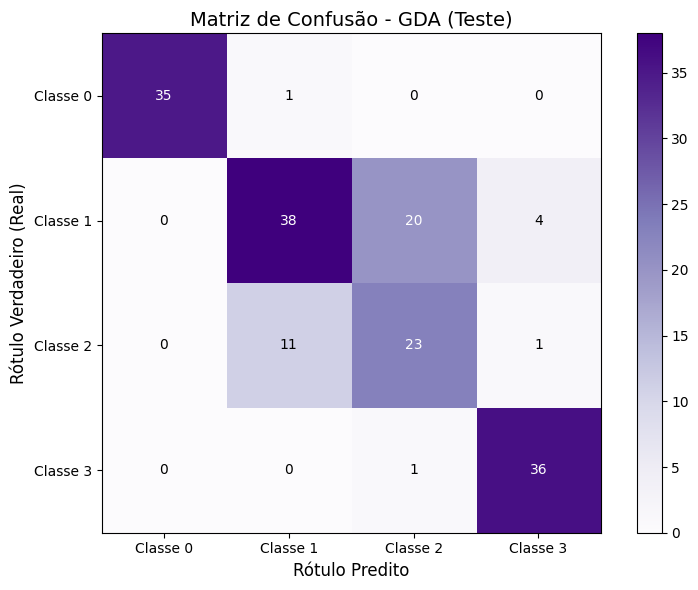

In [ ]:
num_classes = 4

print("Resultados GDA \n")
acc_cv, desvio_cv, acc_cls_cv, desvio_cls_cv = k_fold_split_gda(X_treino, y_treino, 10, num_classes)

print(f"Acurácia Global Média (K-Fold): {acc_cv:.4f} (Desvio: {desvio_cv:.4f})\n")
for c in range(num_classes):
    print(f"Classe {c} -> Acurácia Média: {acc_cls_cv[c]:.4f} (Desvio: {desvio_cls_cv[c]:.4f})")



# agora, treinamento final
media_final = np.mean(X_treino, axis=0)
desvio_final = np.std(X_treino, axis=0) + 1e-8

X_treino_norm = (X_treino - media_final) / desvio_final
X_teste_norm = (X_teste - media_final) / desvio_final

phis_f, mus_f, sigmas_f = treinar_gda(X_treino_norm, y_treino, num_classes)
y_pred_teste = prever_gda(X_teste_norm, phis_f, mus_f, sigmas_f, num_classes)

acc_final = np.mean(y_pred_teste == y_teste)
print(f'\n(Análise do Discriminante Gaussiano)')
print(f'Acurácia final no conjunto de Teste: {acc_final:.4f}')


# agora plotar matriz
def calcular_matriz_confusao(y_real, y_pred, num_classes):
    matriz = np.zeros((num_classes, num_classes), dtype=int)
    for real, pred in zip(y_real, y_pred):
        matriz[int(real), int(pred)] += 1
    return matriz


# a ia me ajudou pra isso
def plotar_matriz_confusao(matriz, num_classes):
    plt.figure(figsize=(8, 6))
    plt.imshow(matriz, interpolation='nearest', cmap='Purples') 
    plt.title('Matriz de Confusão - GDA (Teste)', fontsize=14)
    plt.colorbar()
    
    ticks = np.arange(num_classes)
    nomes_classes = [f'Classe {i}' for i in range(num_classes)]
    plt.xticks(ticks, nomes_classes)
    plt.yticks(ticks, nomes_classes)
    plt.ylabel('Rótulo Verdadeiro (Real)', fontsize=12)
    plt.xlabel('Rótulo Predito', fontsize=12)
    
    limite_cor = matriz.max() / 2.0
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, str(matriz[i, j]),
                     horizontalalignment="center",
                     verticalalignment="center",
                     color="white" if matriz[i, j] > limite_cor else "black")
            
    plt.tight_layout()
    plt.show()

matriz_gda = calcular_matriz_confusao(y_teste, y_pred_teste, num_classes)
plotar_matriz_confusao(matriz_gda, num_classes)

In [14]:
# agora, vamos ao naive bayes gaussiano (GNB)

def treinar_gnb(X, y, num_classes):

    n_features = X.shape[1]
    
    phis = np.zeros(num_classes)              
    mus = np.zeros((num_classes, n_features)) 
    vars_ = np.zeros((num_classes, n_features))
    
    for c in range(num_classes):
        X_c = X[y == c]
        m_c = len(X_c)
        
        phis[c] = m_c / len(X)
        
        mus[c] = np.mean(X_c, axis=0)
        
        vars_[c] = np.var(X_c, axis=0) + 1e-9
        
    return phis, mus, vars_

def prever_gnb(X, phis, mus, vars_, num_classes):
    
    m = len(X)
    scores = np.zeros((m, num_classes))
    
    for c in range(num_classes):
        
        diff = X - mus[c]
        
        log_prob_features = -0.5 * np.log(2 * np.pi * vars_[c]) - 0.5 * (diff**2 / vars_[c])
        
        scores[:, c] = np.log(phis[c]) + np.sum(log_prob_features, axis=1)
        
    return np.argmax(scores, axis=1)

In [15]:
def k_fold_split_gnb(X, y, k, num_classes):
    
    indices_kfold = np.arange(len(X))
    folds = np.array_split(indices_kfold, k)
    
    resultados_globais = []
    resultados_por_classe = {c: [] for c in range(num_classes)}

    for i in range(k):
        val_idx = folds[i]
        treino_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_treinov_puro, X_val_puro = X[treino_idx], X[val_idx]
        y_treinov, y_val = y[treino_idx], y[val_idx]

        media_treino = np.mean(X_treinov_puro, axis=0)
        desvio_treino = np.std(X_treinov_puro, axis=0) + 1e-8
        
        X_treinov = (X_treinov_puro - media_treino) / desvio_treino
        X_val = (X_val_puro - media_treino) / desvio_treino
                
        # agora, treinar
        phis, mus, vars_ = treinar_gnb(X_treinov, y_treinov, num_classes)

        # por fim, predição final
        y_pred_val = prever_gnb(X_val, phis, mus, vars_, num_classes)

        # acurácia global
        acc = np.mean(y_pred_val == y_val)
        resultados_globais.append(acc)

        # acurácia por classe
        for c in range(num_classes):
            mascara = (y_val == c)
            if np.sum(mascara) > 0:
                acc_c = np.mean(y_pred_val[mascara] == c)
                resultados_por_classe[c].append(acc_c)

    media_global = np.mean(resultados_globais)
    desvio_global = np.std(resultados_globais)
    
    media_cls = {c: np.mean(resultados_por_classe[c]) for c in range(num_classes)}
    desvio_cls = {c: np.std(resultados_por_classe[c]) for c in range(num_classes)}

    return media_global, desvio_global, media_cls, desvio_cls

Resultados GNB 

Acurácia Global Média (K-Fold): 0.4526 (Desvio: 0.0719)

Classe 0 -> Acurácia Média: 0.2168 (Desvio: 0.0982)
Classe 1 -> Acurácia Média: 0.2659 (Desvio: 0.1324)
Classe 2 -> Acurácia Média: 0.5178 (Desvio: 0.0904)
Classe 3 -> Acurácia Média: 0.8439 (Desvio: 0.1015)
------------------------------

(Naive Bayes Gaussiano)
Acurácia final no conjunto de Teste: 0.4588


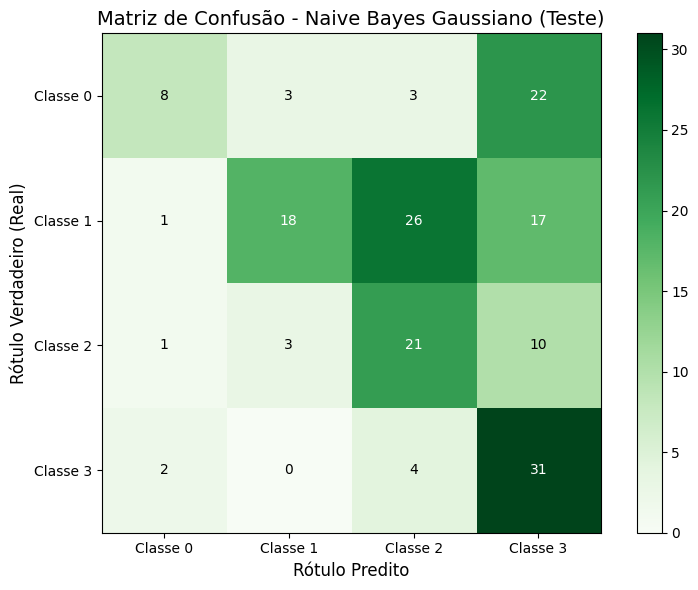

In [ ]:
num_classes = 4

print("Resultados GNB \n")
acc_cv, desvio_cv, acc_cls_cv, desvio_cls_cv = k_fold_split_gnb(X_treino, y_treino, 10, num_classes)

print(f"Acurácia Global Média (K-Fold): {acc_cv:.4f} (Desvio: {desvio_cv:.4f})\n")
for c in range(num_classes):
    print(f"Classe {c} -> Acurácia Média: {acc_cls_cv[c]:.4f} (Desvio: {desvio_cls_cv[c]:.4f})")
print("-" * 30)

media_final = np.mean(X_treino, axis=0)
desvio_final = np.std(X_treino, axis=0) + 1e-8

X_treino_norm = (X_treino - media_final) / desvio_final
X_teste_norm = (X_teste - media_final) / desvio_final

phis_f, mus_f, vars_f = treinar_gnb(X_treino_norm, y_treino, num_classes)
y_pred_teste = prever_gnb(X_teste_norm, phis_f, mus_f, vars_f, num_classes)

acc_final = np.mean(y_pred_teste == y_teste)
print(f'\n(Naive Bayes Gaussiano)')
print(f'Acurácia final no conjunto de Teste: {acc_final:.4f}')

# fazendo a matriz
def calcular_matriz_confusao(y_real, y_pred, num_classes):
    matriz = np.zeros((num_classes, num_classes), dtype=int)
    for real, pred in zip(y_real, y_pred):
        matriz[int(real), int(pred)] += 1
    return matriz

# plotando ela (ia me ajudou)
def plotar_matriz_confusao(matriz, num_classes):
    plt.figure(figsize=(8, 6))
    plt.imshow(matriz, interpolation='nearest', cmap='Greens') # Usei Verde para diferenciar!
    plt.title('Matriz de Confusão - Naive Bayes Gaussiano (Teste)', fontsize=14)
    plt.colorbar()
    
    ticks = np.arange(num_classes)
    nomes_classes = [f'Classe {i}' for i in range(num_classes)]
    plt.xticks(ticks, nomes_classes)
    plt.yticks(ticks, nomes_classes)
    plt.ylabel('Rótulo Verdadeiro (Real)', fontsize=12)
    plt.xlabel('Rótulo Predito', fontsize=12)
    
    limite_cor = matriz.max() / 2.0
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, str(matriz[i, j]),
                     horizontalalignment="center",
                     verticalalignment="center",
                     color="white" if matriz[i, j] > limite_cor else "black")
            
    plt.tight_layout()
    plt.show()

matriz_gnb = calcular_matriz_confusao(y_teste, y_pred_teste, num_classes)
plotar_matriz_confusao(matriz_gnb, num_classes)